In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

train_pd = pd.read_csv('/content/drive/MyDrive/Machine_learning/Titanic/train.csv')



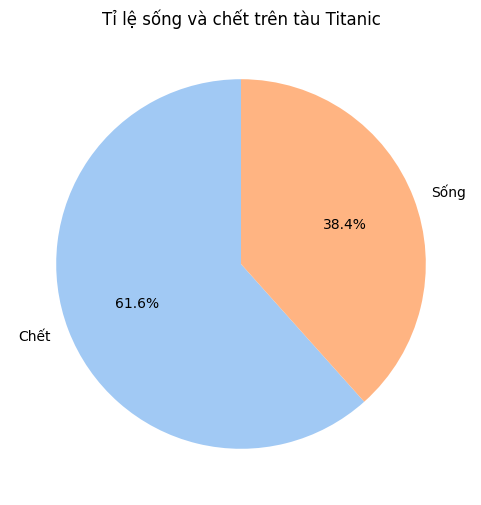

In [5]:
survived_counts = train_pd['Survived'].value_counts().reset_index()
survived_counts.columns = ['Survived', 'Count']

# Đặt tên hiển thị
survived_counts['Status'] = survived_counts['Survived'].map({0:'Chết', 1:'Sống'})

plt.figure(figsize=(6,6))
plt.pie(
    survived_counts['Count'],
    labels=survived_counts['Status'],
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel')
)
plt.title('Tỉ lệ sống và chết trên tàu Titanic')
plt.show()

TypeError: Cell.__init__() got an unexpected keyword argument 'textprops'

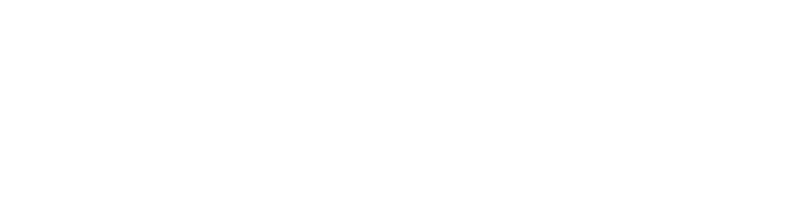

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.table import Table

# Nếu bạn đã có sẵn Titanic dataset:
# train = pd.read_csv('train.csv')
# hoặc bạn có thể tạo demo nhỏ để chạy thử:
data = {
    'PassengerId': [1, 2, 3, 4, 5],
    'Pclass': [3, 1, 3, 1, 3],
    'Name': [
        'Braund, Mr. Owen Harris',
        'Cumings, Mrs. John Bradley',
        'Heikkinen, Miss. Laina',
        'Futrelle, Mrs. Jacques Heath',
        'Allen, Mr. William Henry'
    ],
    'Sex': ['male', 'female', 'female', 'female', 'male'],
    'Age': [22, 38, 26, 35, 35],
    'SibSp': [1, 1, 0, 1, 0],
    'Parch': [0, 0, 0, 0, 0],
    'Fare': [7.25, 71.2833, 7.925, 53.1, 8.05],
    'Embarked': ['S', 'C', 'S', 'S', 'S'],
    'Survived': [0, 1, 1, 1, 0]
}
df = pd.DataFrame(data)

# Chọn cột để hiển thị (gọn cho poster)
cols = ['PassengerId', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Survived']

# ----- Vẽ bảng bằng Matplotlib -----
fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('off')

# Tạo bảng
table = Table(ax, bbox=[0, 0, 1, 1])
n_rows, n_cols = df[cols].shape
width, height = 1.0 / n_cols, 1.0 / (n_rows + 1)

# Header
for j, col in enumerate(cols):
    table.add_cell(0, j, width, height, text=col, loc='center', facecolor='#3c8dbc', textprops={'color':'white', 'weight':'bold', 'fontsize':9})

# Nội dung
for i in range(n_rows):
    for j, col in enumerate(cols):
        val = df.iloc[i, df.columns.get_loc(col)]
        table.add_cell(i+1, j, width, height, text=str(val),
                       loc='center', facecolor='#f7f9fc', textprops={'fontsize':8})

# Kẻ viền trắng giữa ô
for cell in table.get_celld().values():
    cell.set_edgecolor('#e0e0e0')

ax.add_table(table)

# Tiêu đề
plt.title("Titanic Dataset Preview", fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


In [ ]:
train_pd.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
train_pd.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
train_pd.set_index(train_pd.PassengerId, inplace=True)
train_pd.drop(['PassengerId'],axis=1,inplace=True)
train_pd

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [ ]:
test_pd = pd.read_csv('/content/drive/MyDrive/Machine_learning/Titanic/test.csv',index_col='PassengerId')
test_pd

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S


Phân loại các đặc trung

In [ ]:
train_pd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [ ]:
test_pd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 418 entries, 892 to 1309
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Name      418 non-null    object 
 2   Sex       418 non-null    object 
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    object 
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     object 
 9   Embarked  418 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 35.9+ KB


In [ ]:
train_pd["Survived"]=train_pd['Survived'].astype('category')
convert_features=['Pclass','Sex','SibSp','Parch','Embarked']
def convert_cat(df, features):
  for feature in features:
    df[feature]=df[feature].astype('category')
  return df
train_pd=convert_cat(train_pd,convert_features)
test_pd=convert_cat(test_pd,convert_features)

In [ ]:
train_pd.describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


In [ ]:
train_pd.describe(include=['category'])

,Survived,Pclass,Sex,SibSp,Parch,Embarked
count,891,891,891,891,891,889
unique,2,3,2,7,7,3
top,0,3,male,0,0,S
freq,549,491,577,608,678,644


Trên tổng 891 => đã có 549 người bị thiệt mạng
Vé đông nhất là giá vé hạng rẻ nhất => Hiển nhiên
Cảng đông nhất => S

In [ ]:
##EDA


In [ ]:
##Target Variable: Survived

train_pd['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [ ]:
train_pd["Survived"].value_counts(normalize=True).to_frame()

,proportion
Survived,
0,0.616162
1,0.383838


In [ ]:
##SEX


In [ ]:
train_pd['Sex'].value_counts(normalize=True).to_frame()


,proportion
Sex,
male,0.647587
female,0.352413


<Axes: xlabel='Sex', ylabel='count'>

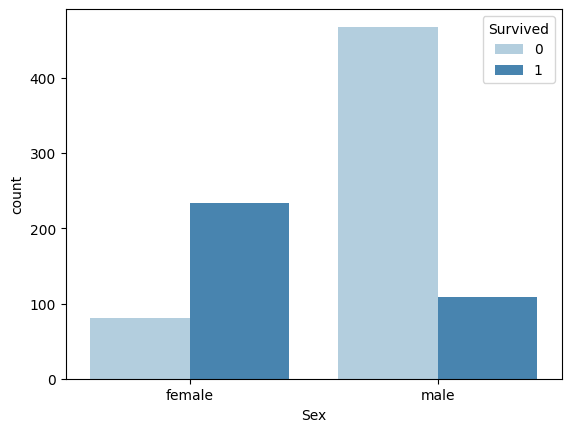

In [ ]:
sns.countplot(data=train_pd,x='Sex',hue='Survived',palette='Blues')

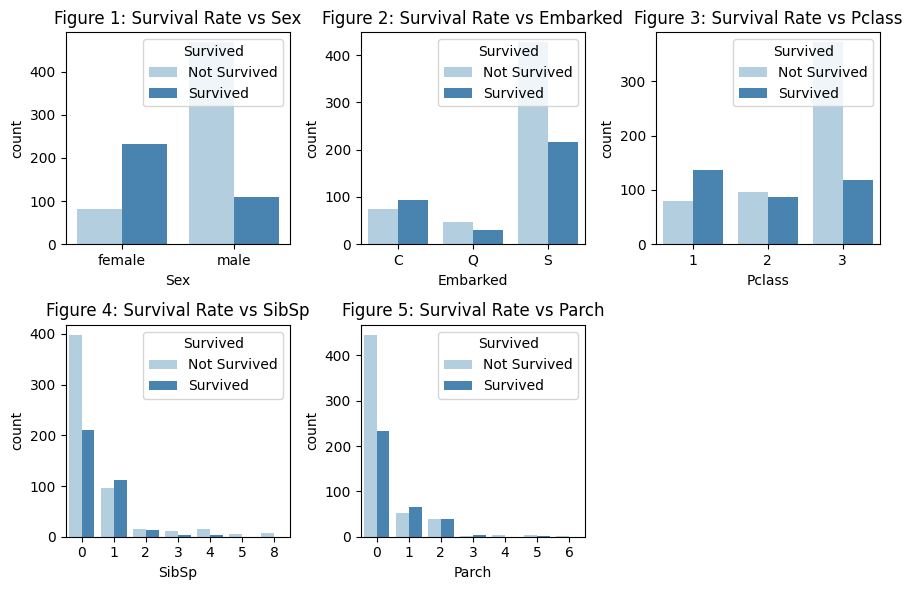

In [ ]:
cols = ['Sex', 'Embarked','Pclass','SibSp','Parch']
n_rows=2
n_cols=3
fig, ax = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
for r in range(0, n_rows):
  for c in range(0,n_cols):
    i = r*n_cols+c
    if i<len(cols):
      ax_i=ax[r,c]
      sns.countplot(data=train_pd,x=cols[i],hue='Survived',ax=ax_i,palette='Blues')
      ax_i.set_title(f"Figure {i+1}: Survival Rate vs {cols[i]}")
      ax_i.legend(title='Survived',loc='upper right', labels=['Not Survived', 'Survived'])
ax.flat[-1].set_visible(False)
plt.tight_layout()




<Axes: xlabel='Age', ylabel='Count'>

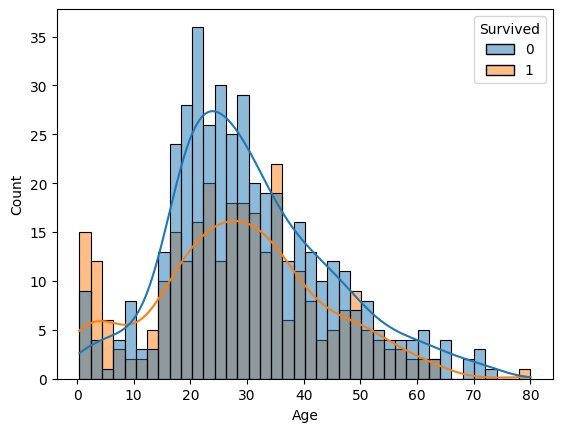

In [ ]:
# Age
sns.histplot(data=train_pd,x='Age',hue='Survived',bins=40, kde=True)


FARE

In [ ]:
train_pd["Fare"].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


<Axes: xlabel='Fare', ylabel='Count'>

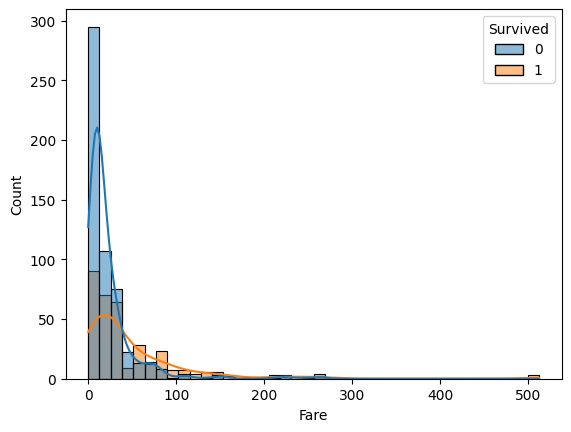

In [ ]:
sns.histplot(data=train_pd,x='Fare',hue='Survived',bins=40, kde=True)

<Axes: xlabel='Fare', ylabel='count'>

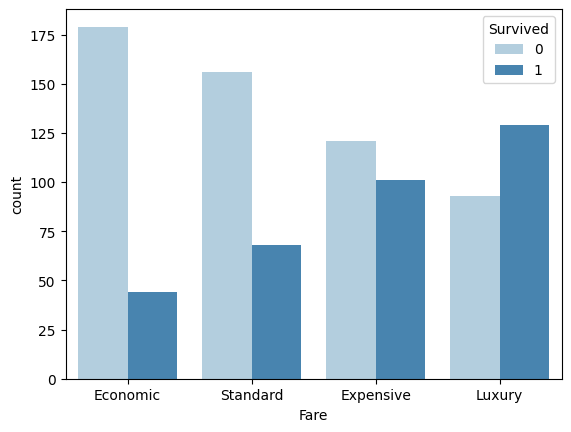

In [ ]:
fare_categories=['Economic','Standard','Expensive','Luxury']


quartile_Data=pd.qcut(train_pd['Fare'],4,labels=fare_categories)
sns.countplot(x=quartile_Data,hue=train_pd['Survived'],palette='Blues')


PHẦN 3: FEATURE ENGINEERING : BIỂU DIỄN TẬP DỮ LIỆU TỐT HƠN

In [ ]:
train_pd['Name'].tail(10)

,Name
PassengerId,
882,"Markun, Mr. Johann"
883,"Dahlberg, Miss. Gerda Ulrika"
884,"Banfield, Mr. Frederick James"
885,"Sutehall, Mr. Henry Jr"
886,"Rice, Mrs. William (Margaret Norton)"
887,"Montvila, Rev. Juozas"
888,"Graham, Miss. Margaret Edith"
889,"Johnston, Miss. Catherine Helen ""Carrie"""
890,"Behr, Mr. Karl Howell"


In [ ]:
import re
def extract_title(name):
  p= re.compile(r", ([\w\s]+)\.")
  return p.search(name).groups(1)[0].strip()

train_pd['Title']=train_pd['Name'].apply(lambda x: extract_title(x))

In [ ]:
train_pd['Title'].value_counts()

,count
Title,
Mr,517
Miss,182
Mrs,125
Master,40
Dr,7
Rev,6
Col,2
Mlle,2
Major,2


In [ ]:
test_pd['Title']=test_pd['Name'].apply(lambda x: extract_title(x))
test_pd['Title'].value_counts()

,count
Title,
Mr,240
Miss,78
Mrs,72
Master,21
Col,2
Rev,2
Ms,1
Dr,1
Dona,1


<Axes: xlabel='Title', ylabel='count'>

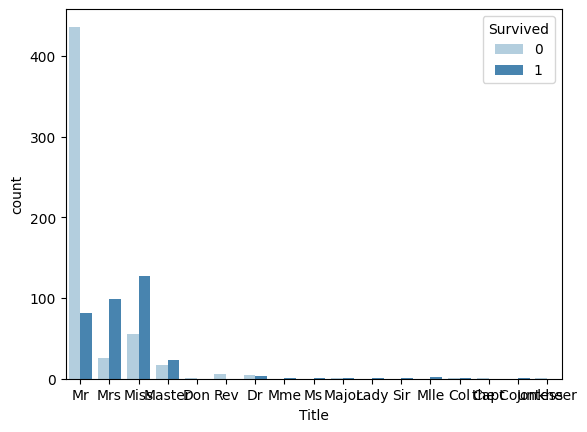

In [ ]:
sns.countplot(data=train_pd,x='Title',hue='Survived',palette='Blues')

In [ ]:
def group_title(title):
  if title in ['Mr','Mrs','Miss','Master']:
    return title
  elif title =="Ms":
    return "Miss"
  else:
    return "Others"
train_pd['Title']=train_pd['Title'].apply(lambda title: group_title(title))

In [ ]:
test_pd['Title']=test_pd['Title'].apply(lambda title: group_title(title))

In [ ]:
train_pd['Title'].value_counts()

,count
Title,
Mr,517
Miss,183
Mrs,125
Master,40
Others,26


<Axes: xlabel='Title', ylabel='count'>

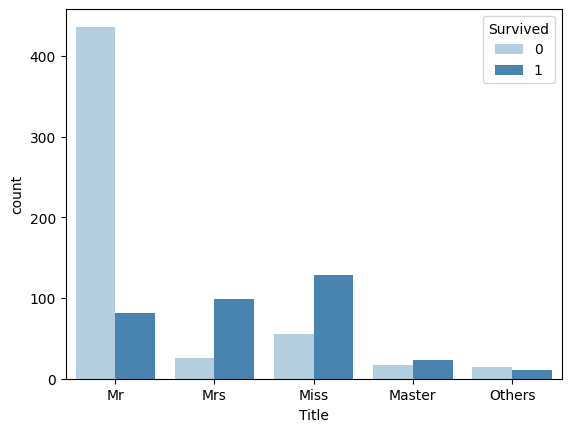

In [ ]:
sns.countplot(data=train_pd,x='Title',hue='Survived',palette='Blues')

FAMILYYYYYYYYYYYYYYYYYYY


In [ ]:
train_pd['FamilySize']=train_pd['SibSp'].astype('int')+train_pd['Parch'].astype('int')+1
test_pd['FamilySize']=test_pd['SibSp'].astype('int')+test_pd['Parch'].astype('int')+1

In [ ]:
train_pd['FamilyCat']=pd.cut(train_pd['FamilySize'],bins=[0,1,4,6,20], labels=['Solo','Small','Medium','Large'])
test_pd['FamilyCat']=pd.cut(test_pd['FamilySize'],bins=[0,1,4,6,20], labels=['Solo','Small','Medium','Large'])

<Axes: xlabel='FamilyCat', ylabel='count'>

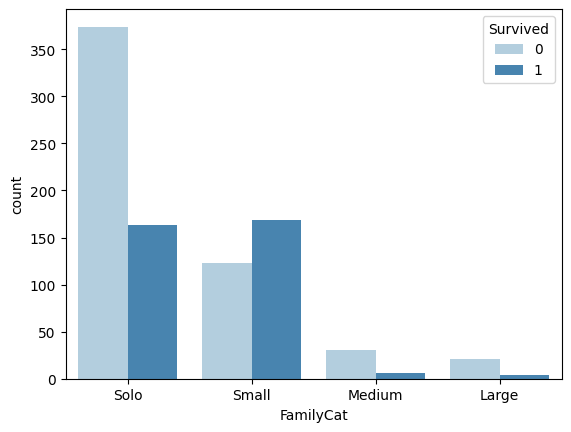

In [ ]:
sns.countplot(data=train_pd,x='FamilyCat',hue='Survived',palette='Blues')

DATA WRANGLING  -> Chuyen tu du lieu tho -> sang

In [ ]:
num_features=['Age','Fare']
cat_features = ['Sex','Pclass','Embarked','Title','FamilyCat']

In [ ]:
featute_cols= num_features+cat_features

In [ ]:
def display_missing(df,featute_cols):
  n_rows=df.shape[0]
  for col in featute_cols:
    missing_count=df[col].isnull().sum()
    if missing_count>0:
      print(f"Col {col} has {missing_count*100/n_rows:.2f}%  missing values")
display_missing(train_pd,featute_cols)
display_missing(test_pd,featute_cols)

Col Age has 19.87%  missing values
Col Embarked has 0.22%  missing values
Col Age has 20.57%  missing values
Col Fare has 0.24%  missing values


Filling missing values
AGE **bold text**
- Filling missing values with median of whole dataset


In [ ]:
age_by_sex_pclass=train_pd.groupby(['Sex','Pclass'])['Age'].median()
age_by_sex_pclass

/tmp/ipython-input-2872589390.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_by_sex_pclass=train_pd.groupby(['Sex','Pclass'])['Age'].median()


Sex     Pclass
female  1         35.0
        2         28.0
        3         21.5
male    1         40.0
        2         30.0
        3         25.0
Name: Age, dtype: float64

In [ ]:
train_pd['Age'] = train_pd.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

test_pd['Age'] = test_pd.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))



/tmp/ipython-input-692387614.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_pd['Age'] = train_pd.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))
/tmp/ipython-input-692387614.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test_pd['Age'] = test_pd.groupby(['Sex','Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))


In [ ]:
display_missing(train_pd,featute_cols)
display_missing(test_pd,featute_cols)

Col Embarked has 0.22%  missing values
Col Fare has 0.24%  missing values


In [ ]:
X=train_pd[featute_cols]
y=train_pd['Survived']

In [ ]:
X_test=test_pd[featute_cols]

In [ ]:

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [ ]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

In [ ]:
preprocessor.fit(X)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'Fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Sex', 'Pclass', 'Embarked', 'Title',
                                  'FamilyCat'])])

In [ ]:
X= preprocessor.transform(X)
X_test=preprocessor.transform(X_test)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2)

In [ ]:
X_train.shape, X_val.shape

((712, 19), (179, 19))

In [ ]:
X_test.shape

(418, 19)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report

In [ ]:
log_reg= LogisticRegression(solver="liblinear")
log_reg.fit(X_train,y_train)


LogisticRegression(solver='liblinear')

In [ ]:
log_reg.score(X_val,y_val)

0.8212290502793296

In [ ]:
y_pred = log_reg.predict(X_val)

In [ ]:
precision_score(y_val,y_pred) , recall_score(y_val,y_pred)


(0.75, 0.7727272727272727)

In [ ]:
print(classification_report(y_val,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.85      0.86       113
           1       0.75      0.77      0.76        66

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [ ]:
test_pd.head()

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,FamilyCat
PassengerId,,,,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,Mr,1,Solo
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,Mrs,2,Small
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,Mr,1,Solo
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,Mr,1,Solo
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,Mrs,3,Small


In [ ]:
preds = log_reg.predict(X_test)
submission = pd.DataFrame({
    'PassengerId': test_pd.index,
    'Survived': preds.astype(int)
})



In [ ]:
submission.to_csv('/content/drive/MyDrive/Machine_learning/Titanic/submission.csv', index=False)